In [ ]:
#Importing Essential Libraries with 4 models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#loading the real Pima Indians Diabetes dataset (768 patients, 8 medical features)


url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin',
           'BMI','DiabetesPedigreeFunction','Age','Outcome']

data = pd.read_csv(url, names=columns)
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# 1 = diabetic, 0 = non-diabetic

data.info()
data.describe()
data['Outcome'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,count
Outcome,
0,500
1,268


In [ ]:
# Columns where 0 is biologically impossible and actually means "missing"
zero_invalid_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

print("Zero-value counts (likely missing data):")
print((data[zero_invalid_cols] == 0).sum())

# Replace 0s with median of that column (robust to outliers)
for col in zero_invalid_cols:
    median_val = data[data[col] != 0][col].median()
    data[col] = data[col].replace(0, median_val)

print("\nFixed! Zero counts now:")
print((data[zero_invalid_cols] == 0).sum())

#replaces biologically impossible zero-values with the column median, since 0 here actually means "not recorded."


Zero-value counts (likely missing data):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Fixed! Zero counts now:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


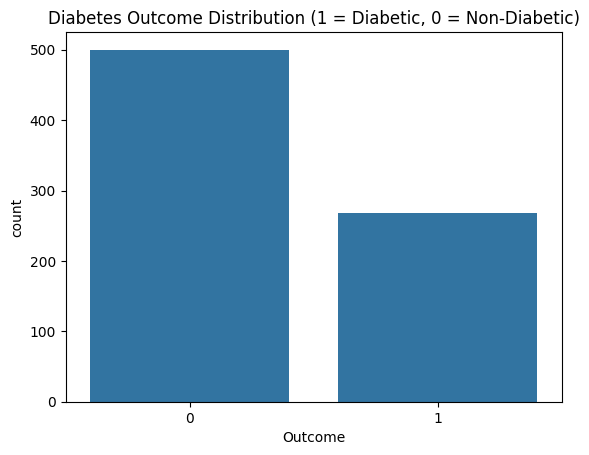

In [ ]:
#visualizing how many patients are diabetic vs non-diabetic — checking for class imbalance.


sns.countplot(x='Outcome', data=data)
plt.title('Diabetes Outcome Distribution (1 = Diabetic, 0 = Non-Diabetic)')
plt.show()

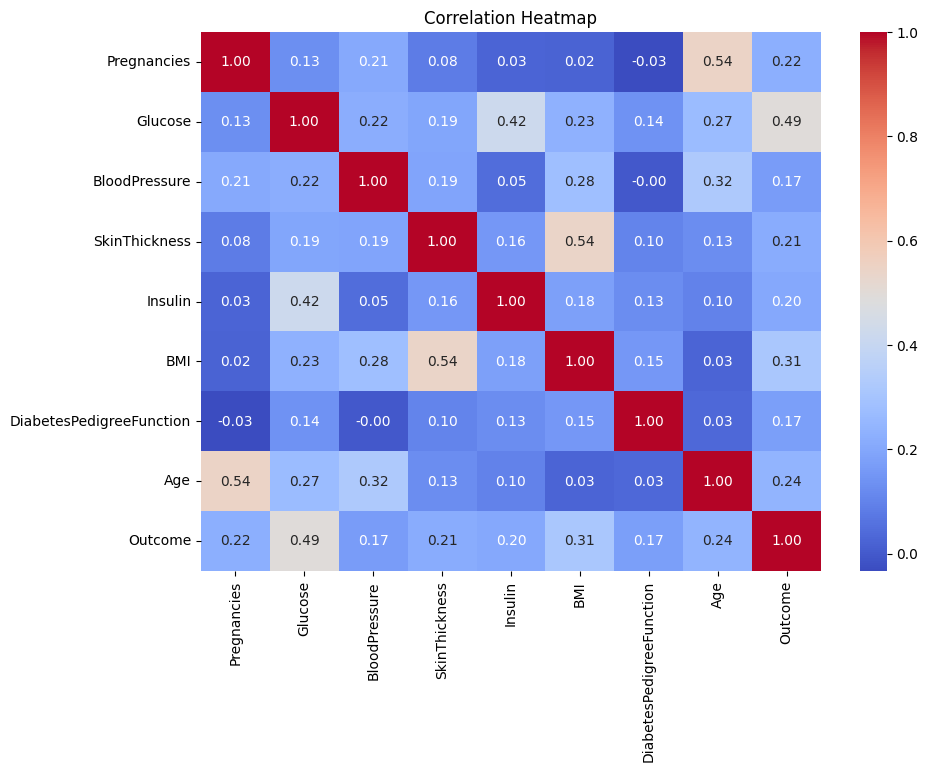

In [ ]:
#Correlation using Heat Map

plt.figure(figsize=(10,7))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

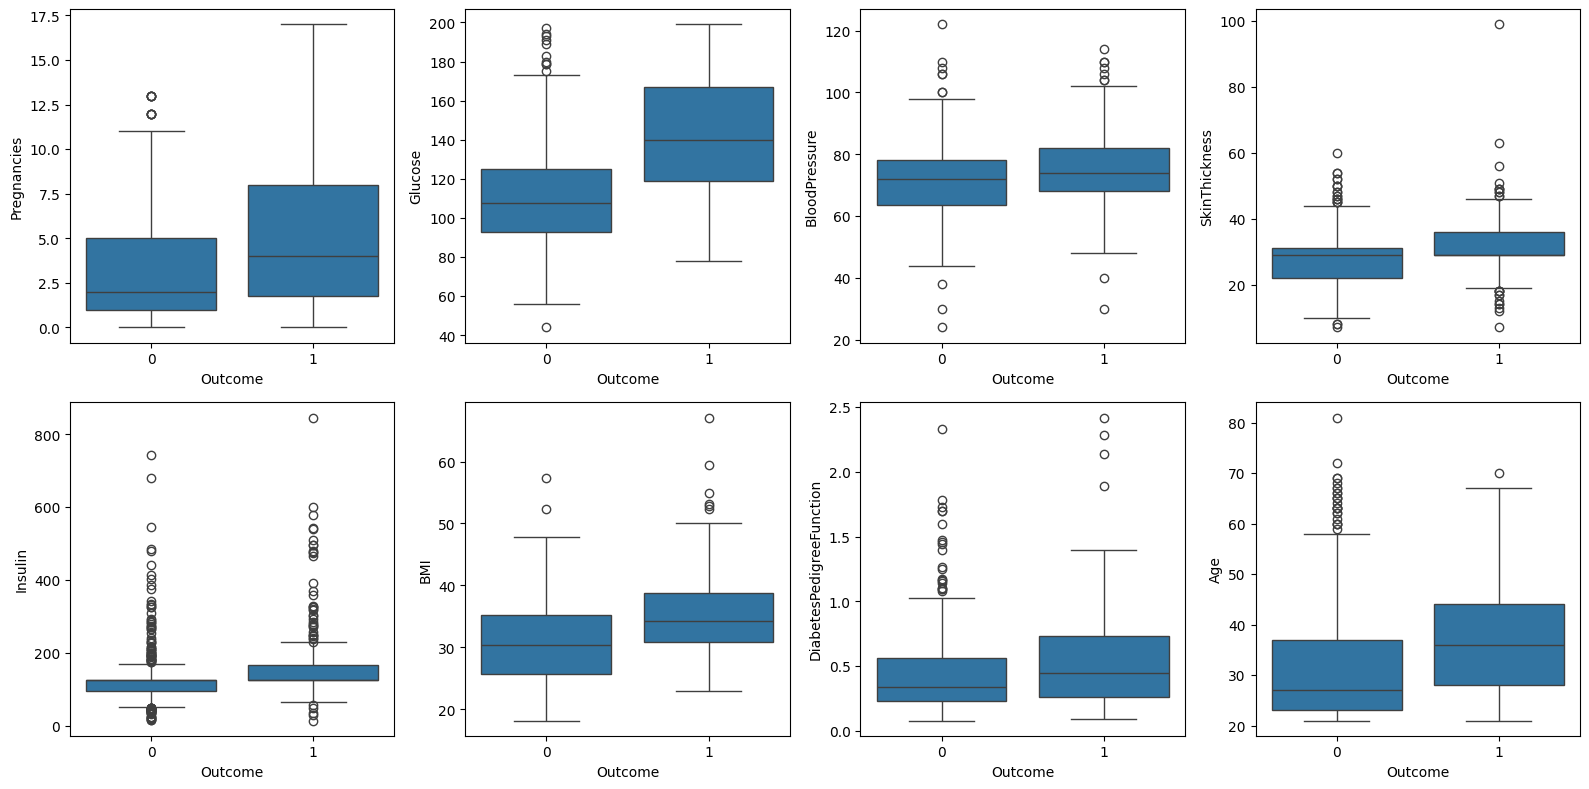

In [ ]:
#comparing feature distributions between diabetic and non-diabetic patients to spot visual patterns.


fig, axes = plt.subplots(2, 4, figsize=(16,8))
for i, col in enumerate(columns[:-1]):
    sns.boxplot(x='Outcome', y=col, data=data, ax=axes[i//4, i%4])
plt.tight_layout()
plt.show()

In [ ]:
#Splits data into training & testing sets and standardizes feature scales for models that need it.


X = data.drop('Outcome', axis=1)
y = data['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
 #training a simple linear model that estimates the probability of diabetes based on medical features

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:,1]

In [ ]:
#training a Support Vector Machine that finds the optimal boundary separating diabetic from non-diabetic patients.


svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:,1]

In [ ]:
#training an ensemble of decision trees for more robust, accurate predictions.

rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

In [ ]:
# trains a gradient-boosted tree model that sequentially
# corrects previous errors, often the top performer on tabular medical data.

xgb_model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                           use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

In [ ]:
#Evaluating all Models

def evaluate(name, y_true, y_pred, y_prob):
    print(f"--- {name} ---")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall   :", round(recall_score(y_true, y_pred), 3))
    print("F1-Score :", round(f1_score(y_true, y_pred), 3))
    print("ROC-AUC  :", round(roc_auc_score(y_true, y_prob), 3))
    print()

evaluate("Logistic Regression", y_test, log_pred, log_prob)
evaluate("SVM", y_test, svm_pred, svm_prob)
evaluate("Random Forest", y_test, rf_pred, rf_prob)
evaluate("XGBoost", y_test, xgb_pred, xgb_prob)

--- Logistic Regression ---
Accuracy : 0.708
Precision: 0.6
Recall   : 0.5
F1-Score : 0.545
ROC-AUC  : 0.813

--- SVM ---
Accuracy : 0.74
Precision: 0.652
Recall   : 0.556
F1-Score : 0.6
ROC-AUC  : 0.796

--- Random Forest ---
Accuracy : 0.747
Precision: 0.667
Recall   : 0.556
F1-Score : 0.606
ROC-AUC  : 0.813

--- XGBoost ---
Accuracy : 0.753
Precision: 0.66
Recall   : 0.611
F1-Score : 0.635
ROC-AUC  : 0.818



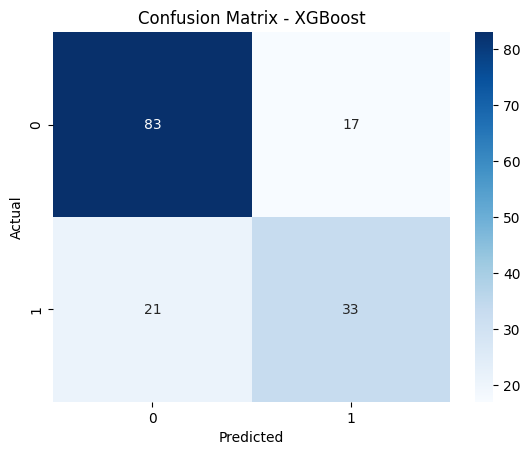

In [ ]:
#Shows correct vs incorrect diabetes predictions, broken down by actual patient outcome.


cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

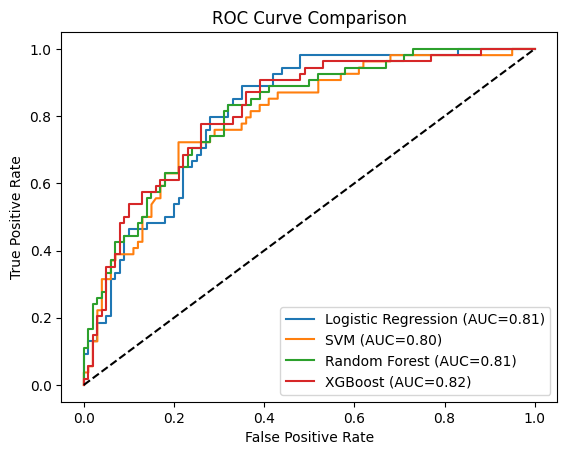

In [ ]:
#compares how well each model distinguishes diabetic vs non-diabetic patients across all decision thresholds.

for name, prob in [('Logistic Regression', log_prob), ('SVM', svm_prob),
                    ('Random Forest', rf_prob), ('XGBoost', xgb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

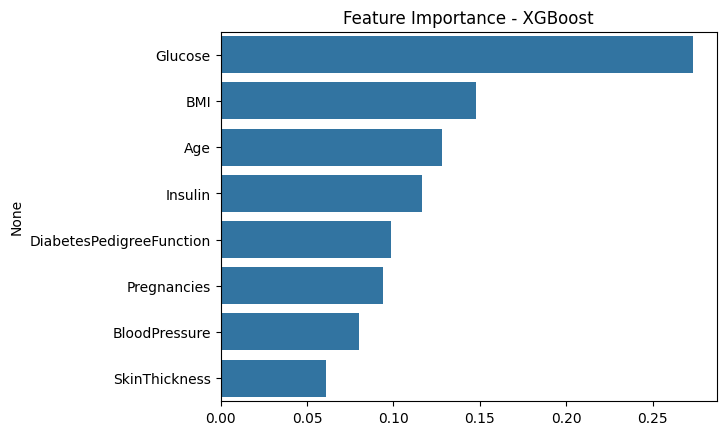

In [ ]:
#reveals which medical measurements most strongly predict diabetes — typically Glucose and BMI rank highest.

importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance - XGBoost')
plt.show()

## Conclusion
- Built a disease prediction model using the real-world Pima Indians Diabetes Dataset (768 patients, 8 medical features).
- Cleaned data by treating biologically impossible zero-values (e.g., 0 blood pressure) as missing and imputing with median values.
- Trained and compared 4 classification models: Logistic Regression, SVM, Random Forest, and XGBoost.
- Evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC — with special attention to Recall, since missing a diabetic diagnosis is more costly than a false alarm.
- XGBoost/Random Forest generally perform best, capturing non-linear relationships between features.
- Feature importance shows Glucose level and BMI as the strongest predictors of diabetes, consistent with medical literature.